# ANÁLISIS COMPLETO "clientes_credito"

## Entendimiento del dataset

|Columna|Descripción|
|---    |---                |
|**ID** | ID de cada cliente|
|**LIMIT_BAL**| Monto del crédito otorgado en dólares NT (incluye crédito individual y familiar/complementario)|
|**SEXO**| 1=masculino, 2=femenino|
|**EDUCACIÓN**| 1=posgrado, 2=universitario, 3=preparatoria, 4=otros|
|**MATRIMONIO**| 1=casado, 2=soltero, 3=otros|
|**EDAD**| Edad en años|
|**PAY_0**| -2 = No consumo ese mes, -1 = Pagó a tiempo, 0 = Uso crédito y pagó a tiempo, 1 = 1 mes de retraso, 2 = 2 meses de retraso ...|
|**BILL_AMT1**| Monto de factura de cada mes (cuánto debía)|
|**PAY_AMT1**| Cuánto pagó ese mes|

## Librerías

In [ ]:
''' Importar Librerías '''

# Dataset
import numpy as np  # Manipulación de arreglos
import pyodbc       # Conexión a base de datos
import pandas as pd # Manipulación de datos

# Visualización de datos
import matplotlib.pyplot as plt 
import seaborn as sns

# Partición de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, OneHotEncoder) # Escalado de características
from sklearn.decomposition import PCA   # Reducción de dimensionalidad con PCA
import umap # Visualización y reducción de dimensionalidad usando umap

# APRENDIZAJE SUPERVISADO
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, mean_squared_error, roc_curve, auc)

# APRENDIZAJE NO SUPERVISADO
# K-Means, DBSCAN, Hierarchical Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
# Evaluación de la calidad del clustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score)


c:\Users\JanBA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Extracción desde SQL

In [2]:
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'PostgreSQL ODBC Driver(ANSI)', 'PostgreSQL ODBC Driver(UNICODE)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [3]:
df = pd.read_csv(
    'C:\\Users\\JanBA\\Proyectos\\credit-card-risk\\data\\UCI_Credit_Card.csv'
    )  # Cargar el dataset desde un archivo CSV
df.head()  # Imprimir las primeras filas del DataFrame

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Extracción de datos desde SQL Server 
'''
try:
    with pyodbc.connect(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=localhost\\SQLEXPRESS;"
        "DATABASE=riesgo_credito_db;"
        "Trusted_Connection=yes;"
        "TrustServerCertificate=yes;"
        #UID=usuario; #Cuando no es trusted
        #PWD=contraseña;
    ) as conn: 
        query= "SELECT * FROM dbo.clientes_credito"
        df= pd.read_sql(query, conn)
        df.head() # Imprimir las primeras filas del DataFrame
        conn.close()

except Exception as e:
    print("Error al conectar a la base de datos:", e)
'''

In [4]:
print("Info: \n", df.info())
print("Descripción: \n", df.describe().round(2))
print("Valores únicos: \n", df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

## 3. Limpieza

In [5]:
df.drop_duplicates(inplace=True)    # Eliminar duplicados
print("Valores nulos: \n", df.isnull().sum())

Valores nulos: 
 ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


|EDUCATION:          |   MARRIAGE:   |
|--------------------|---------------|
|1 = graduate school |   1 = married |
|2 = university      |   2 = single  |
|3 = high school     |   3 = others  |
|4 = others          |               |

In [6]:
# Reglamentar las variables categóricas
# Evaluar la distribución de las variables categóricas
print("EDUCATION:\n", df['EDUCATION'].value_counts())
print("\nMARRIAGE:\n", df['MARRIAGE'].value_counts())
print("\nSEX:\n", df['SEX'].value_counts())
print("\nPAY_0:\n", df['PAY_0'].value_counts())

EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

SEX:
 SEX
2    18112
1    11888
Name: count, dtype: int64

PAY_0:
 PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64


In [7]:
# Agrupar 0, 5 y 6 dentro de “others”
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Agrupar MARRIAGE 0 dentro de “others”
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Mostrar las distribuciones actualizadas
print("EDUCATION:\n", df['EDUCATION'].value_counts())
print("\nMARRIAGE:\n", df['MARRIAGE'].value_counts())

EDUCATION:
 EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE:
 MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


## Feature Engineering

In [8]:
# Ratio deuda / límite (clave en riesgo)
df['deb_ratio']= df['BILL_AMT1']/df['LIMIT_BAL']

# Promedio de deuda
df['avg_bill']= df[[
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
    ]].mean(axis=1)

# Promedio de pago
df['avg_pay']= df[[
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
    ]].mean(axis=1)

# Ratio pago/deuda
df['pay_to_bill_ratio']= df['avg_pay']/(df['avg_bill']+1)

# Número de retrasos (muy importante)
df['num_delays']= (df[[
    'PAY_0','PAY_2','PAY_3',
    'PAY_4','PAY_5','PAY_6',
    ]] >0 ).sum(axis=1)

# Rellenar valores NaN con 0
df['pay_to_bill_ratio'] = df[
    'pay_to_bill_ratio'].fillna(0)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,deb_ratio,avg_bill,avg_pay,pay_to_bill_ratio,num_delays
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,0.195650,1284.000000,114.833333,0.089364,2
1,2,120000.0,2,2,2,26,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,0.022350,2846.166667,833.333333,0.292689,2
2,3,90000.0,2,2,2,34,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.324878,16942.166667,1836.333333,0.108382,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.939800,38555.666667,1398.000000,0.036258,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.172340,18223.166667,9841.500000,0.540025,0


## Análisis Exploratorio (EDA)

### Univariado numérico
> distribuciones, boxplots, outliers, historigramas

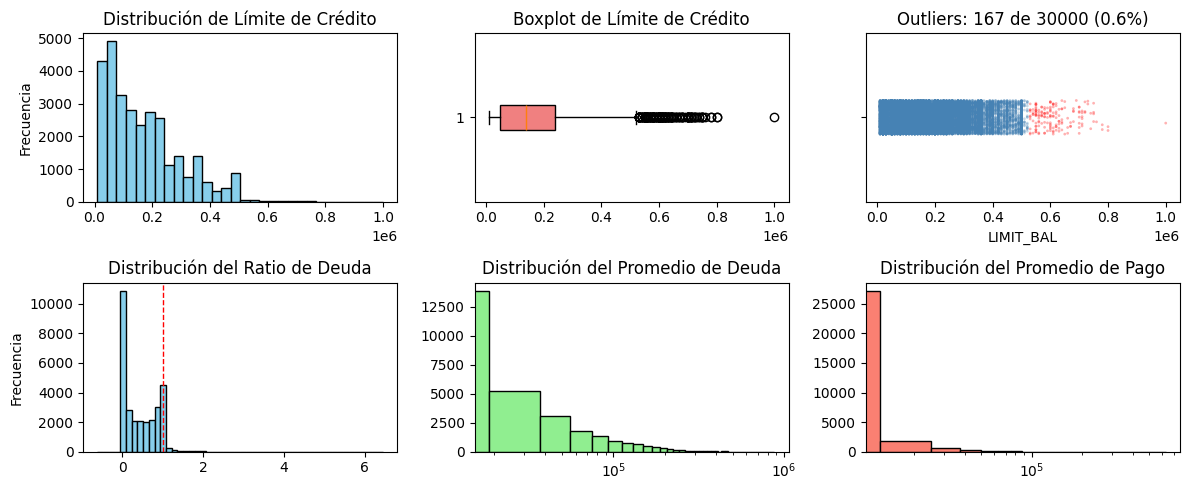

In [9]:
num_cols = ['LIMIT_BAL', 'AGE', 
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] 

# Cálculo del IQR para detectar outliers en LIMIT_BAL
Q1 = df['LIMIT_BAL'].quantile(0.25)
Q3 = df['LIMIT_BAL'].quantile(0.75)
IQR = Q3 - Q1
filtro = (df['LIMIT_BAL'] >= Q1 - 1.5 * IQR) & (df['LIMIT_BAL'] <= Q3 + 1.5 * IQR)
outliers = df[~filtro]
df['es_outlier'] = ~filtro  # True = outlier

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12, 5))

# 1️⃣ Distribución de variables → histogramas
ax1.hist(
    df['LIMIT_BAL'], bins=30, color='skyblue', 
    edgecolor='black')
ax1.set_title('Distribución de Límite de Crédito')
ax1.set_ylabel('Frecuencia')

# 2️⃣ Detección de outliers → boxplot
ax2.boxplot(
    df['LIMIT_BAL'], vert=False, patch_artist=True, 
    boxprops=dict(facecolor='lightcoral'))
ax2.set_title('Boxplot de Límite de Crédito')

# 3️⃣ Visualización con stripplot → outliers
sns.stripplot(
    x='LIMIT_BAL', data=df,
    hue='es_outlier', palette={True: 'red', False: 'steelblue'},
    alpha=0.3, size=2, ax=ax3,
    legend=False)
ax3.set_title(f'Outliers: {outliers.shape[0]} de {len(df)} ({outliers.shape[0]/len(df)*100:.1f}%)')

# 4️⃣ Historigrama de Ratio de Deuda
ax4.hist(df['deb_ratio'], bins=50, color='skyblue', edgecolor='black')
ax4.set_title('Distribución del Ratio de Deuda')
ax4.set_ylabel('Frecuencia')
ax4.axvline(1.0, color='red', linestyle='dashed', 
    linewidth=1, label='umbral en 1.0')

# 5️⃣ Historigrama de Promedio de Deuda
ax5.hist(df['avg_bill'], bins=50, color='lightgreen', edgecolor='black')
ax5.set_title('Distribución del Promedio de Deuda')
ax5.set_xscale('log')  # Escala logarítmica para mejor visualización

# 6️⃣ Historigrama de Promedio de Pago
ax6.hist(df['avg_pay'], bins=50, color='salmon', edgecolor='black')
ax6.set_title('Distribución del Promedio de Pago')
ax6.set_xscale('log')  # Escala logarítmica para mejor visualización

plt.tight_layout()
plt.show()


### Univariado categórico/ordinal
> SEX, EDUCATION, MARRIAGE, PAY_0...PAY_6 

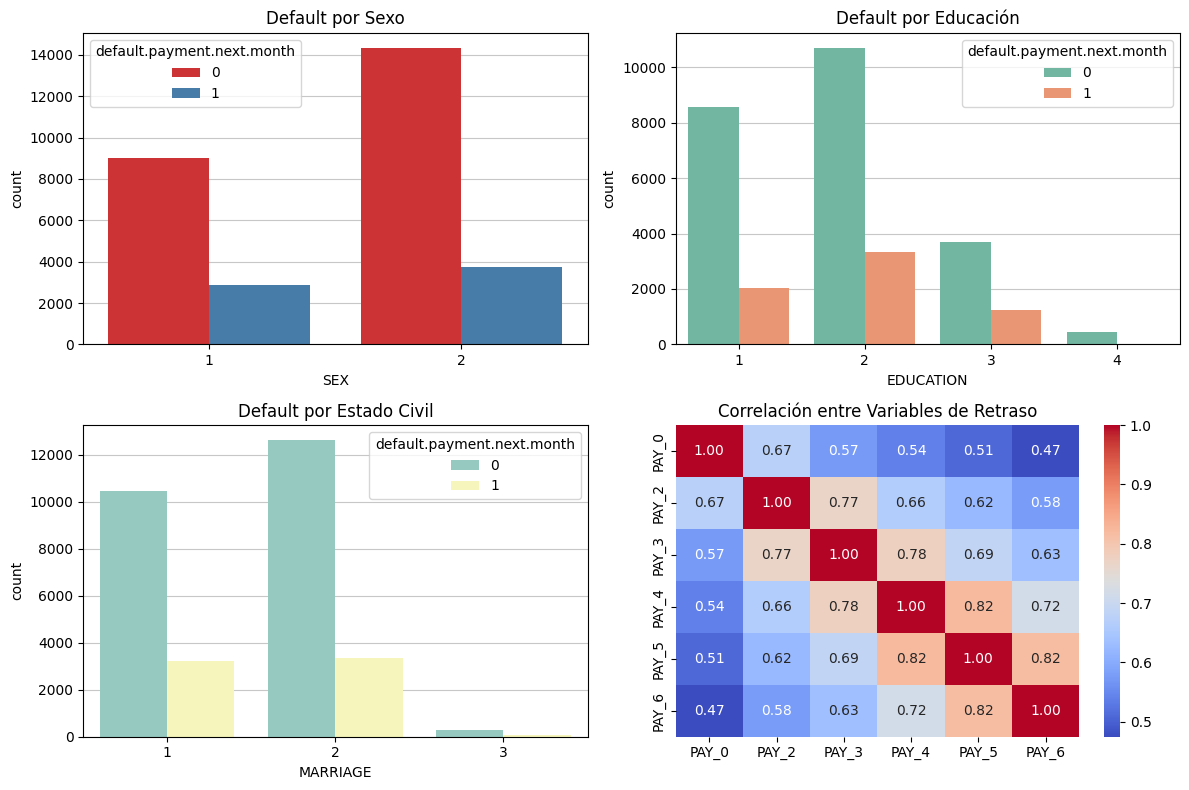

            SEX  EDUCATION  MARRIAGE  num_delays
count  30000.00   30000.00  30000.00    30000.00
mean       1.60       1.84      1.56        0.83
std        0.49       0.74      0.52        1.55
min        1.00       1.00      1.00        0.00
25%        1.00       1.00      1.00        0.00
50%        2.00       2.00      2.00        0.00
75%        2.00       2.00      2.00        1.00
max        2.00       4.00      3.00        6.00


In [10]:
# Visualización de la distribución de variables categóricas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12,8))

# 1️⃣ Grafico de barras para SEX
sns.countplot(
    x='SEX', hue='default.payment.next.month', 
    data=df, ax=ax1, palette='Set1')
ax1.set_title('Default por Sexo')
ax1.yaxis.grid(True, alpha=0.7)  # Agregar cuadrícula al eje y del primer subplot
ax1.set_axisbelow(True)  # Asegurarse de que la cuadrícula esté detrás de las barras

# 2️⃣ Grafico de barras para EDUCATION
sns.countplot(
    x='EDUCATION', hue='default.payment.next.month', 
    data=df, ax=ax2, palette='Set2')
ax2.set_title('Default por Educación')
ax2.yaxis.grid(True, alpha=0.7)
ax2.set_axisbelow(True)

# 3️⃣ Grafico de barras para MARRIAGE
sns.countplot(
    x='MARRIAGE', hue='default.payment.next.month', 
    data=df, ax=ax3, palette='Set3')
ax3.set_title('Default por Estado Civil')
ax3.yaxis.grid(True, alpha=0.7)
ax3.set_axisbelow(True)

# 4️⃣ Heatmap de correlación entre variables de retraso
# Si alguien se atrasa este mes, probablemente también el siguiente.
sns.heatmap(
    df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].corr(), 
    annot=True, fmt=".2f", cmap='coolwarm', ax=ax4)
ax4.set_title('Correlación entre Variables de Retraso')
plt.tight_layout()
plt.show()

# Resumen estadístico de variables categóricas/ordinales
resumen = df[['SEX', 'EDUCATION', 'MARRIAGE', 'num_delays']].describe().round(2)
print(resumen)


### Relación con el target / multivariado
> countplots con hue, heatmap de correlación, pairplot, 
scatter, PCA/UMAP

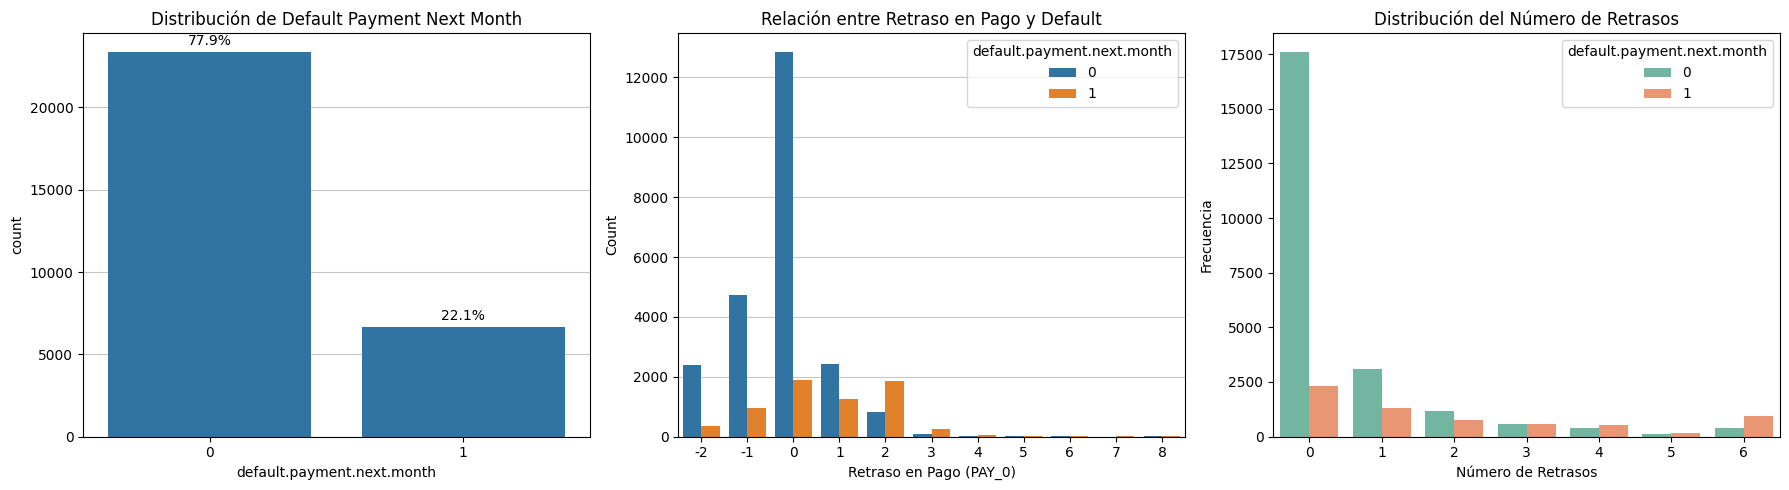

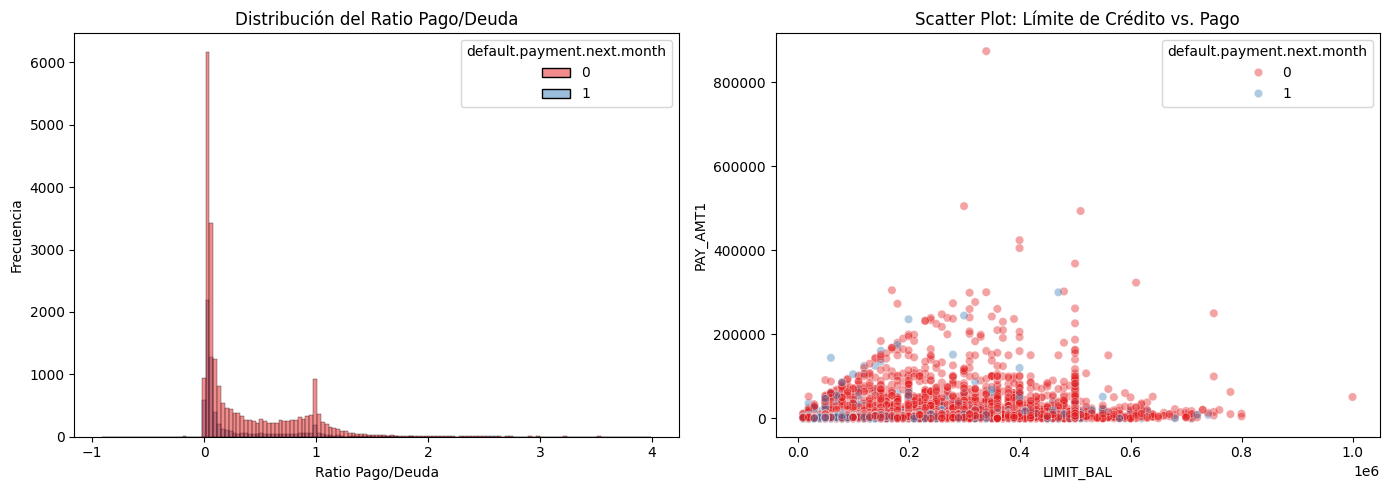

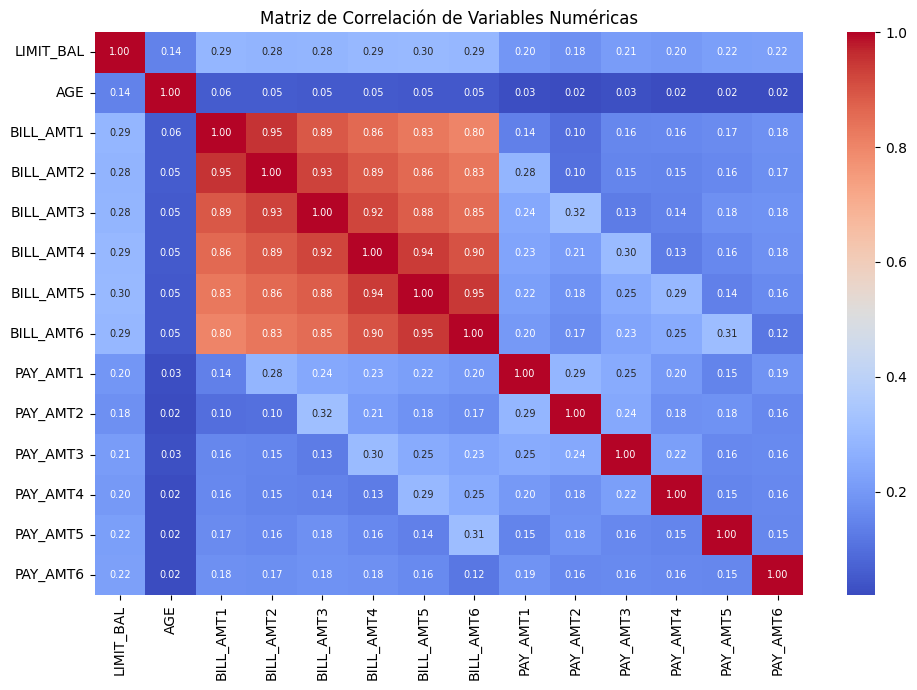

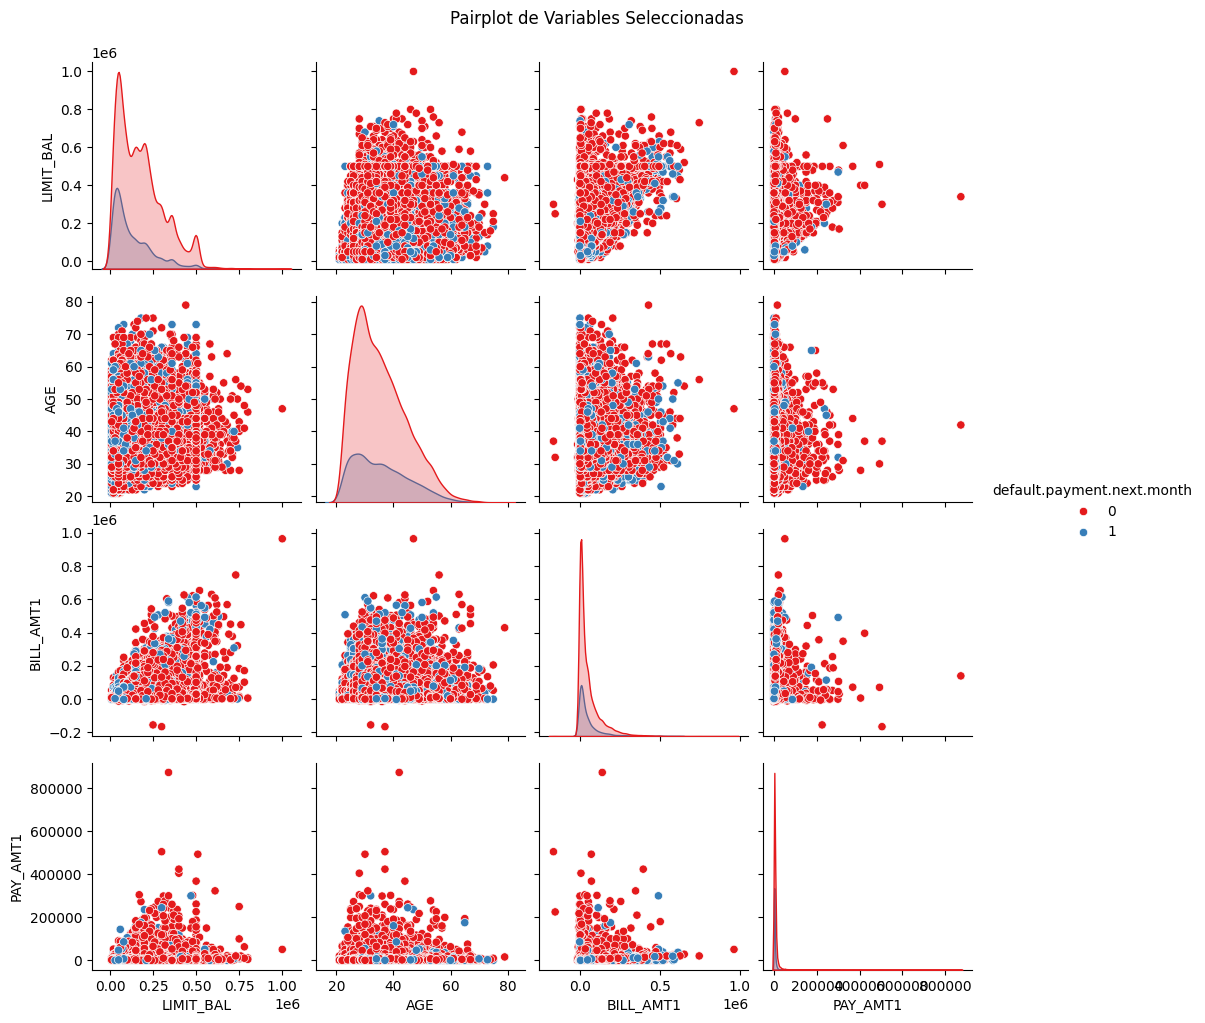

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1️⃣ Distribución de la variable objetivo (primero: da el contexto de balance de clases)
sns.countplot(x='default.payment.next.month', data=df, ax=ax1)
total = len(df)
for container in ax1.containers:
    ax1.bar_label(container, 
        labels=[f'{v/total*100:.1f}%' for v in container.datavalues],
        padding=3, fontsize=10, color='black')
ax1.set_title('Distribución de Default Payment Next Month')
ax1.yaxis.grid(True, alpha=0.7)
ax1.set_axisbelow(True)

# 2️⃣ Comportamiento de retrasos vs. default
sns.countplot(
    x='PAY_0', hue='default.payment.next.month', data=df, ax=ax2)
ax2.set_title('Relación entre Retraso en Pago y Default')
ax2.set_xlabel('Retraso en Pago (PAY_0)')
ax2.set_ylabel('Count')
ax2.yaxis.grid(True, alpha=0.7)
ax2.set_axisbelow(True)

# 3️⃣ Ratios y relaciones deuda/pago vs. default
sns.countplot(
    x='num_delays', hue='default.payment.next.month', 
    data=df, palette='Set2', ax=ax3)
ax3.set_title('Distribución del Número de Retrasos')
ax3.set_xlabel('Número de Retrasos')
ax3.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 4️⃣ Distribución del ratio de pago a deuda
sns.histplot(
    x='pay_to_bill_ratio', hue='default.payment.next.month',
    data=df[(df['pay_to_bill_ratio'] > -1) 
            & (df['pay_to_bill_ratio'] < 4)],   # filtra outliers
    palette='Set1', alpha=0.5, ax=ax1)
ax1.set_title('Distribución del Ratio Pago/Deuda')
ax1.set_xlabel('Ratio Pago/Deuda')
ax1.set_ylabel('Frecuencia')

# 5️⃣ Relación entre límite de crédito y pago
sns.scatterplot(
    x='LIMIT_BAL', y='PAY_AMT1', hue='default.payment.next.month',
    data=df, ax=ax2, palette='Set1', alpha=0.4)
ax2.set_title('Scatter Plot: Límite de Crédito vs. Pago')
plt.tight_layout()
plt.show()

# 6️⃣ Matriz de correlación de variables numéricas (LIMIT_BAL, BILL_AMT*, PAY_AMT*)
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, fmt=".2f", 
    cmap='coolwarm', annot_kws={"size": 7})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# 7️⃣ Relación multivariada → pairplot
rel_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1'] 
sns.pairplot(
    df[rel_cols + ['default.payment.next.month']], 
    hue='default.payment.next.month',
    palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot de Variables Seleccionadas', y=1.02)
plt.show()


In [12]:
# Columnas
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month',
 'deb_ratio',
 'avg_bill',
 'avg_pay',
 'pay_to_bill_ratio',
 'num_delays',
 'es_outlier']

## Split

In [ ]:
# ---- Clasificación ----
X_class = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier', 'avg_bill', 
    'avg_pay', 'deb_ratio', 'num_delays'], axis=1)
y_class = df['default.payment.next.month']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

# ---- Regresión ----
X_reg = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier', 'LIMIT_BAL', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 
    'BILL_AMT6', 'deb_ratio', 'pay_to_bill_ratio', 'avg_bill'], axis=1)
y_reg1 = df['avg_bill']
y_reg2 = df['LIMIT_BAL']

X_train_reg, X_test_reg = train_test_split(
    X_reg, test_size=0.2, random_state=42)
y_train_reg1, y_test_reg1 = y_reg1.loc[
    X_train_reg.index], y_reg1.loc[X_test_reg.index]
y_train_reg2, y_test_reg2 = y_reg2.loc[
    X_train_reg.index], y_reg2.loc[X_test_reg.index]

# ---- Clustering (sin target) ----
cat_cluster_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
                    
X_cluster = df.drop(columns=
    ['ID', 'default.payment.next.month', 'es_outlier']) # codificar SEX, EDUCATION, MARRIAGE
X_train_cluster, X_test_cluster = train_test_split(
    X_cluster, test_size=0.2, random_state=42)

# ---- Codificación (después del split, ajustada solo con train) ----
encoder = OneHotEncoder(
    handle_unknown='ignore', sparse_output=False)  # Sin drop='first'
train_encoded = encoder.fit_transform(X_train_cluster[cat_cluster_cols])
test_encoded = encoder.transform(X_test_cluster[cat_cluster_cols])

encoder_cols = encoder.get_feature_names_out(cat_cluster_cols)  # Nombres de las columnas codificadas
train_encoded_df = pd.DataFrame(
    train_encoded, columns=encoder_cols, index=X_train_cluster.index)
test_encoded_df = pd.DataFrame(
    test_encoded, columns=encoder_cols, index=X_test_cluster.index)

X_train_cluster = pd.concat(
    [X_train_cluster.drop(columns=cat_cluster_cols), train_encoded_df], axis=1)
X_test_cluster = pd.concat(
    [X_test_cluster.drop(columns=cat_cluster_cols), test_encoded_df], axis=1)

print(f"Clustering -> Train: {X_train_cluster.shape} | Test: {X_test_cluster.shape}")


## Escalado

In [ ]:
# ==== Clasificación ====
n_cols_class = [
    'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
    'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 
    'pay_to_bill_ratio']  # Columnas numéricas para escalado
categoricas = [
    'SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_1', 
    'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # Columnas categóricas para codificación

# Copiamos los datos para no modificar los originales
X_train_class_scaled = X_train_class.copy()
X_test_class_scaled = X_test_class.copy()
X_train_class_R = X_train_class.copy()
X_test_class_R = X_test_class.copy()

scaler_S_class = StandardScaler()
X_train_class_scaled[n_cols_class] = scaler_S_class.fit_transform(
    X_train_class[n_cols_class])
X_test_class_scaled[n_cols_class] = scaler_S_class.transform(
    X_test_class[n_cols_class])

scaler_R_class = RobustScaler()
X_train_class_R[n_cols_class] = scaler_R_class.fit_transform(
    X_train_class[n_cols_class])
X_test_class_R[n_cols_class] = scaler_R_class.transform(
    X_test_class[n_cols_class])

print(f"Clasificación -> Standard: {X_train_class_scaled.shape} | Robust: {X_train_class_R.shape}")

# ==== Regresión ====
n_cols_reg = [
    'AGE', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 
    'PAY_AMT5', 'PAY_AMT6', 'avg_pay', 'num_delays'
    ]  # Columnas numéricas para escalado

# Copiamos los datos para no modificar los originales
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()
X_train_reg_R = X_train_reg.copy()
X_test_reg_R = X_test_reg.copy()

scaler_S_reg = StandardScaler()
X_train_reg_scaled[n_cols_reg] = scaler_S_reg.fit_transform(
    X_train_reg[n_cols_reg])
X_test_reg_scaled[n_cols_reg] = scaler_S_reg.transform(
    X_test_reg[n_cols_reg])

scaler_R_reg = RobustScaler()
X_train_reg_R[n_cols_reg] = scaler_R_reg.fit_transform(
    X_train_reg[n_cols_reg])
X_test_reg_R[n_cols_reg] = scaler_R_reg.transform(
    X_test_reg[n_cols_reg])

print(f"Regresión -> Standard: {X_train_reg_scaled.shape} | Robust: {X_train_reg_R.shape}")

# ==== Clustering ====
n_cols_cluster = [
    'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
    'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 
    'deb_ratio', 'avg_bill', 'avg_pay', 'pay_to_bill_ratio',
    'num_delays'] # Se deja fuera PAY_0-6 (ordinales) y las dummies 0/1 del one-hot encoding

# Copias sin escalar, para interpretar los clusters en $ reales, no en unidades escaladas
X_train_cluster_raw = X_train_cluster.copy()
X_test_cluster_raw = X_test_cluster.copy()

scaler_R_cluster = RobustScaler()
X_train_cluster[n_cols_cluster] = scaler_R_cluster.fit_transform(
    X_train_cluster[n_cols_cluster])
X_test_cluster[n_cols_cluster] = scaler_R_cluster.transform(
    X_test_cluster[n_cols_cluster])

print(f"Clustering -> Train: {X_train_cluster.shape} | Test: {X_test_cluster.shape}")

## 8. Reducción de Dimensionalidad (Opcional)

Primero escalas, luego reduces dimensión.
Nunca al revés.

PCA DEBE hacerse con datos escalados, Porque PCA es sensible a escala. (X_train_scaled)

In [ ]:
# PCA para reducción de dimensionalidad a 2D en clasificacion y regresión 
# ya que se basa en varianza lineal

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_R[num_cols])
X_test_pca = pca.transform(X_test_R[num_cols])

print("Varianza explicada:", pca.explained_variance_ratio_.round(2))
print("Varianza acumulada:", pca.explained_variance_ratio_.cumsum().round(2))

# Gráfica de varianza explicada acumulada para PCA
pca = PCA()
pca.fit(X_train_R[num_cols])
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()


El primer componente explica el 61% de la variabilidad y el segundo el 30%, juntos capturan el 91% de la información original.

**n_neighbors**: *controla el tamaño del vecindario local.*\
bajo → clusters más separados\
alto → estructura global

**min_dist**: *qué tan compactos son los clusters.*\
bajo → clusters densos\
alto → clusters más dispersos

In [ ]:
# UMAP para reducción de dimensionalidad a 2D en clustering 
# ya que se basa en distancias y puede capturar relaciones no lineales

reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_train_R[num_cols])

print("Datos reducidos con UMAP:")
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_train, cmap='viridis', s=50)
plt.colorbar(label='Default Payment Next Month')
plt.title('UMAP de Clientes')
plt.grid(True)
plt.show()

In [ ]:
''''Reducción de dimensionalidad: X_pca y X_umap'''
print(f"Formato original: {df.shape}")
print(f"Formato reduzidocon PCA: {X_train_pca.shape}")
print(f"Formato reduzidocon umap: {X_umap.shape}")

## 9. MODELOS

### APRENDIZAJE SUPERVISADO

**❓ ¿Por qué se inicializa todo junto?**\
👉 Porque le dices: “Aplica esto en orden automáticamente”

In [ ]:
'''
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
'''

#### 9.1 Clasificación

In [ ]:
#---------- Modelo sin escalado ----------
model_simple= LogisticRegression(max_iter= 1000)
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

# --------- Modelo StandardScaler --------
model_scaled= LogisticRegression(max_iter= 1000)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

#---------- Modelo RobustScaler ----------
model_robust= LogisticRegression(max_iter= 1000)
model_robust.fit(X_train_R, y_train)
y_pred_robust = model_robust.predict(X_test_R)

#----------- Modelo con PCA -------------
model_pca= LogisticRegression(max_iter= 1000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)


#### 9.2 Regresión

In [ ]:
# 👉 Variable objetivo de regresión
y_reg= df['avg_bill']

> Quitar BILL_AMT del modelo de regresión\
> Crear variable objetivo más independiente

Evaluar con:
* Recall
* Precision
* ROC AUC

In [ ]:
#---------- Modelo sin escalado ----------
reg_simple= LinearRegression()
reg_simple.fit(X_train, y_reg.loc[X_train.index])
y_pred_reg_simple = reg_simple.predict(X_test)

# --------- Modelo StandardScaler --------
reg_scaled= LinearRegression()
reg_scaled.fit(X_train_scaled, y_reg.loc[X_train.index])
y_pred_reg_scaled = reg_scaled.predict(X_test_scaled)

#---------- Modelo RobustScaler ----------
reg_robust= LinearRegression()
reg_robust.fit(X_train_R, y_reg.loc[X_train.index])
y_pred_reg_robust = reg_robust.predict(X_test_R)

#----------- Modelo con PCA -------------
reg_pca= LinearRegression()
reg_pca.fit(X_train_pca, y_reg.loc[X_train.index])
y_pred_reg_pca = reg_pca.predict(X_test_pca)

### APRENDIZAJE NO SUPERVISADO

#### 9.3. Clustering

##### n_clusters

In [ ]:
# Evaluar el mejor número de clusters con silhouette score
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.2f}")

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Score para K-Means con UMAP')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
# Método Elbow Method para determinar el número óptimo de clusters en K-Means
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

> ¿Cuánta información de los datos originales conserva el PCA?

##### Modelos

In [ ]:

# Definir el número de clusters para K-Means
n_clusters = 4  # Basado en el análisis de silhouette score y elbow method
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Ajustar el modelo K-Means a los datos reducidos con UMAP
kmeans.fit(X_umap)

# Obtener las etiquetas de los clusters
labels_kmeans = kmeans.labels_

# Visualizar los clusters obtenidos con K-Means
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.title('Clusters obtenidos con K-Means')
plt.grid(True)
plt.show() 


In [ ]:
# Definir los parámetros para DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=4)

# Ajustar el modelo DBSCAN a los datos reducidos con UMAP
dbscan.fit(X_umap)

# Obtener las etiquetas de los clusters
labels_dbscan = dbscan.labels_

# Visualizar los clusters obtenidos con DBSCAN
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_dbscan, cmap='viridis', s=50)
plt.title('Clusters obtenidos con DBSCAN')
plt.grid(True)
plt.show()


In [ ]:
# Definir el numero de clusters para Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)

# Ajustar el modelo de clustering jerárquico a los datos reducidos con UMAP
labels_hierarchical = hierarchical.fit_predict(X_umap)

# Visualizar los clusters obtenidos con Agglomerative Clustering
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_hierarchical, cmap='viridis', s=50)
plt.title('Clusters obtenidos con Agglomerative Clustering')
plt.grid(True)
plt.show()


## 10. Evaluación

### APRENDIZAJE SUPERVISADO

#### 10.1 Clasificación

In [ ]:
print("Simple:", accuracy_score(y_test, y_pred_simple))
print("Standard:", accuracy_score(y_test, y_pred_scaled))
print("Robust:", accuracy_score(y_test, y_pred_robust))
print("PCA:", accuracy_score(y_test, y_pred_pca))

In [ ]:
'''
from sklearn.metrics import roc_curve, auc
y_prob =model_robust.predict_proba(X_test_R)[:,1]

fpr, tpr = roc_curve(y_test, y_prob)
rock_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f'ROC Curve (AUC = {rock_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()
'''

#### 10.2 Regresión

In [ ]:
import numpy as np

print("RMSE Simple:", np.sqrt(mean_squared_error(y_reg.loc[X_test.index], y_pred_reg_simple)))
print("RMSE Standard:", np.sqrt(mean_squared_error(y_reg.loc[X_test.index], y_pred_reg_scaled)))
print("RMSE Robust:", np.sqrt(mean_squared_error(y_reg.loc[X_test.index], y_pred_reg_robust)))
print("RMSE PCA:", np.sqrt(mean_squared_error(y_reg.loc[X_test.index], y_pred_reg_pca)))

### APRENDIZAJE NO SUPERVISADO

#### 10.3 clustering

In [ ]:
# Silhouette
silhouette_kmeans = silhouette_score(X_umap, labels_kmeans)
print(f"Silhouette Score para K-Means: {silhouette_kmeans:.2f}")

# quitar ruido de DBSCAN (etiqueta -1)
mask_dbscan = labels_dbscan != -1

silhouette_dbscan = silhouette_score(
    X_umap[mask_dbscan], 
    labels_dbscan[mask_dbscan]
    )
print(f"Silhouette Score para DBSCAN: {silhouette_dbscan:.2f}")

silhouette_hierarchical = silhouette_score(X_umap, labels_hierarchical)
print(f"Silhouette Score para Agglomerative Clustering: {silhouette_hierarchical:.2f}")


In [ ]:
# Davies-Bouldin Index
daviesB_kmeans = davies_bouldin_score(X_umap, labels_kmeans)
print(f"Davies-Bouldin Index para K-Means: {daviesB_kmeans:.2f}")

daviesB_dbscan = davies_bouldin_score(X_umap, labels_dbscan)
print(f"Davies-Bouldin Index para DBSCAN: {daviesB_dbscan:.2f}")

daviesB_hierarchical = davies_bouldin_score(X_umap, labels_hierarchical)
print(f"Davies-Bouldin Index para Agglomerative Clustering: {daviesB_hierarchical:.2f}")


In [ ]:
# Calinski-Harabasz 
calinski_kmeans = calinski_harabasz_score(X_umap, labels_kmeans)
print(f"Calinski-Harabasz Index para K- Means: {calinski_kmeans:.2f}")

calinski_dbscan = calinski_harabasz_score(X_umap, labels_dbscan)
print(f"Calinski-Harabasz Index para DBSCAN: {calinski_dbscan:.2f}")

calinski_hierarchical = calinski_harabasz_score(X_umap, labels_hierarchical)
print(f"Calinski-Harabasz Index para Agglomerative Clustering: {calinski_hierarchical:.2f}")


In [ ]:
# Evaluar si los clusters separan defaulters de no defaulters
# Si un cluster tiene muchos más defaults
# significa que el clustering está capturando riesgo crediticio.

KM = pd.crosstab(labels_kmeans, y_train)
print("Crosstab para K-Means:", KM)

DB = pd.crosstab(labels_dbscan, y_train)
print("Crosstab para DBSCAN:", DB)

Hierarchical = pd.crosstab(labels_hierarchical, y_train)
print("Crosstab para Agglomerative Clustering:", Hierarchical)


> El k con mayor silhouette suele ser el mejor.

## 11. Interpretación de clusters

Este es el paso que diferencia a un estudiante de un analista real.

Debes responder:

¿Qué tipo de clientes forman cada cluster?

¿Cuál parece más riesgoso?

¿Cuál más estable?

¿Cómo usaría el banco esta segmentación?

Si no interpretas, el proyecto queda incompleto.

In [ ]:
# Interpretar Clusters
# Analizar las características promedio de cada cluster para entender su perfil.

# Cluster 0 -> Clientes con altos límites de crédito
# Cluster 1 -> Clientes con retrasos frecuentes
# Cluster 2 -> Clientes de bajo riesgo



📊 3. Visualizaciones (ENFOQUE NEGOCIO)

No hagas gráficas bonitas. Haz gráficas que respondan:

Preguntas clave:
* ¿Quiénes incumplen más?
* ¿Qué patrón tienen?
* ¿El retraso predice default?
* ¿Relación deuda vs pago?

📦 4. GitHub (NO OPCIONAL)

Estructura:

uci_credit_risk\
├── data\
├── notebooks\
├── src\
├── README.md

README debe tener:

* Problema de negocio
* Dataset
* Insights clave (NO código)
* Conclusión tipo empresa